In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
START_DATE = pd.Timestamp("2013-01-01")
END_DATE = pd.Timestamp("2026-03-10")

DATA_DIR, START_DATE, END_DATE

(PosixPath('/Users/akos/Projects/ESMT-AIS/data'),
 Timestamp('2013-01-01 00:00:00'),
 Timestamp('2026-03-10 00:00:00'))

In [3]:
def read_price_csv(path: Path, date_col: str = "Date"):
    """Read a CSV with a Date index and return a DataFrame restricted to the analysis window."""
    df = pd.read_csv(path, parse_dates=[date_col])
    df = df.set_index(date_col).sort_index()
    return df.loc[(df.index >= START_DATE) & (df.index <= END_DATE)]


def summarize_coverage(df: pd.DataFrame, label: str):
    if df.empty:
        print(f"{label}: NO DATA IN WINDOW {START_DATE.date()}–{END_DATE.date()}")
        return
    first, last = df.index[0], df.index[-1]
    full_range = pd.date_range(START_DATE, END_DATE, freq="B")
    # Align to business-day calendar and look for missing observations
    aligned = df.reindex(full_range)
    missing = aligned["Adj Close" if "Adj Close" in aligned.columns else aligned.columns[0]].isna()
    missing_count = int(missing.sum())
    print(f"{label}: {first.date()} → {last.date()}, rows={len(df)}, missing_bd_obs={missing_count}")

    return missing


def plot_series(df: pd.DataFrame, label: str, use_adj_close: bool = True):
    if df.empty:
        return
    col = "Adj Close" if use_adj_close and "Adj Close" in df.columns else "Close"
    df[col].plot(figsize=(10, 4), title=f"{label} – {col} {START_DATE.date()}–{END_DATE.date()}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.show()

## Commodity ETFs (USO, UNG, GLD, CORN, WEAT)

In [4]:
commodity_etf_files = {
    "USO": DATA_DIR / "USO_etf_data.csv",
    "UNG": DATA_DIR / "UNG_etf_data.csv",
    "GLD": DATA_DIR / "GLD_etf_data.csv",
    "CORN": DATA_DIR / "CORN_etf_data.csv",
    "WEAT": DATA_DIR / "WEAT_etf_data.csv",
}

commodity_etfs = {}
for label, path in commodity_etf_files.items():
    if path.exists():
        df = read_price_csv(path)
        commodity_etfs[label] = df
        print(f"Loaded {label} from {path.name}: {len(df)} rows in window")
    else:
        print(f"Missing file for {label}: {path}")

Loaded USO from USO_etf_data.csv: 3315 rows in window
Loaded UNG from UNG_etf_data.csv: 3315 rows in window
Loaded GLD from GLD_etf_data.csv: 3315 rows in window
Loaded CORN from CORN_etf_data.csv: 3315 rows in window
Loaded WEAT from WEAT_etf_data.csv: 3315 rows in window


USO: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126
UNG: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126
GLD: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126
CORN: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126
WEAT: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126


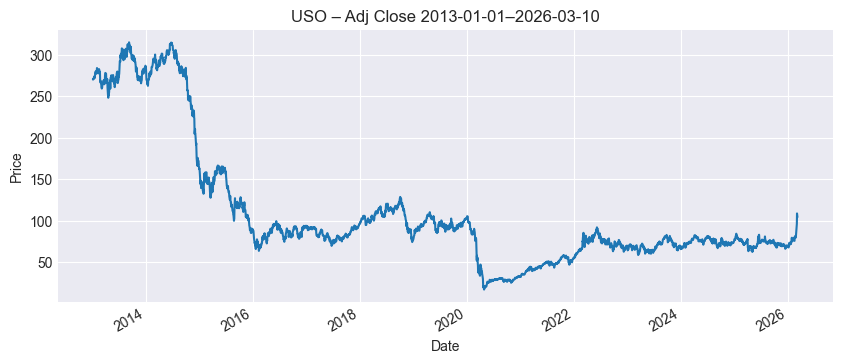

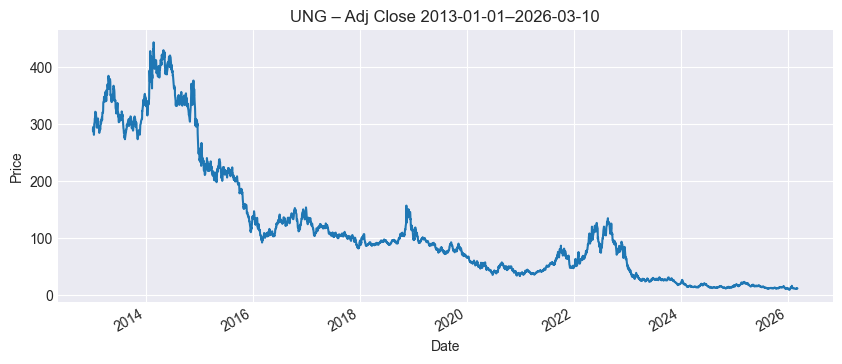

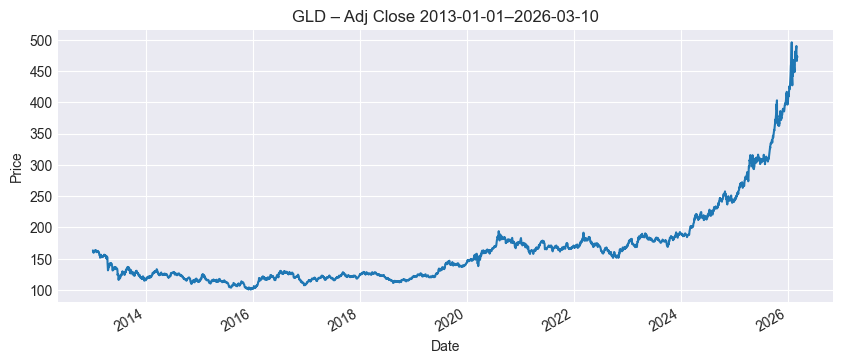

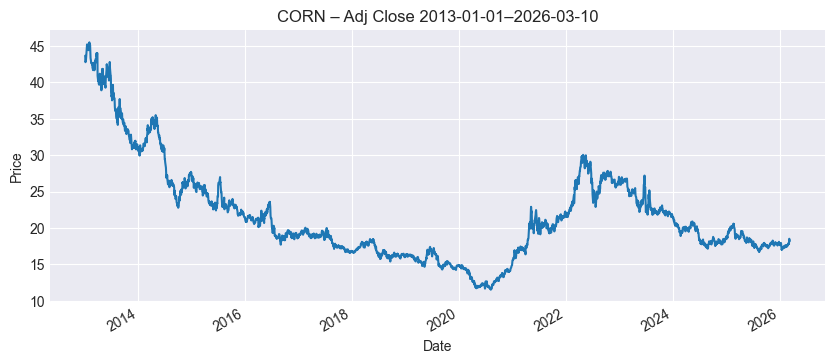

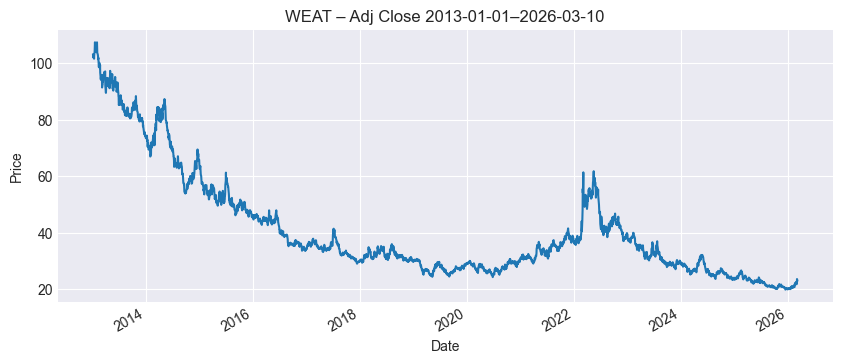

In [5]:
commodity_missing = {}
for label, df in commodity_etfs.items():
    missing = summarize_coverage(df, label)
    commodity_missing[label] = missing

for label, df in commodity_etfs.items():
    plot_series(df, label)

## 10Y Government Bond ETFs

In [6]:
bond_etf_files = {
    "IEF": DATA_DIR / "IEF_etf_data.csv",
    "IS04_DE": DATA_DIR / "IS04_DE_etf_data.csv",
    "IGLT_L": DATA_DIR / "IGLT_L_etf_data.csv",
    "XGB_TO": DATA_DIR / "XGB_TO_etf_data.csv",
    "XJSE_DE": DATA_DIR / "XJSE_DE_etf_data.csv",
    "IGB_AX": DATA_DIR / "IGB_AX_etf_data.csv",
}

bond_etfs = {}
for label, path in bond_etf_files.items():
    if path.exists():
        df = read_price_csv(path)
        bond_etfs[label] = df
        print(f"Loaded {label} from {path.name}: {len(df)} rows in window")
    else:
        print(f"Missing file for {label}: {path}")

Loaded IEF from IEF_etf_data.csv: 3315 rows in window
Loaded IS04_DE from IS04_DE_etf_data.csv: 2773 rows in window
Loaded IGLT_L from IGLT_L_etf_data.csv: 3331 rows in window
Loaded XGB_TO from XGB_TO_etf_data.csv: 3308 rows in window
Loaded XJSE_DE from XJSE_DE_etf_data.csv: 3109 rows in window
Loaded IGB_AX from IGB_AX_etf_data.csv: 3337 rows in window


IEF: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126
IS04_DE: 2015-04-01 → 2026-03-05, rows=2773, missing_bd_obs=668
IGLT_L: 2013-01-02 → 2026-03-09, rows=3331, missing_bd_obs=110
XGB_TO: 2013-01-02 → 2026-03-09, rows=3308, missing_bd_obs=133
XJSE_DE: 2013-12-02 → 2026-03-05, rows=3109, missing_bd_obs=332
IGB_AX: 2013-01-02 → 2026-03-09, rows=3337, missing_bd_obs=104


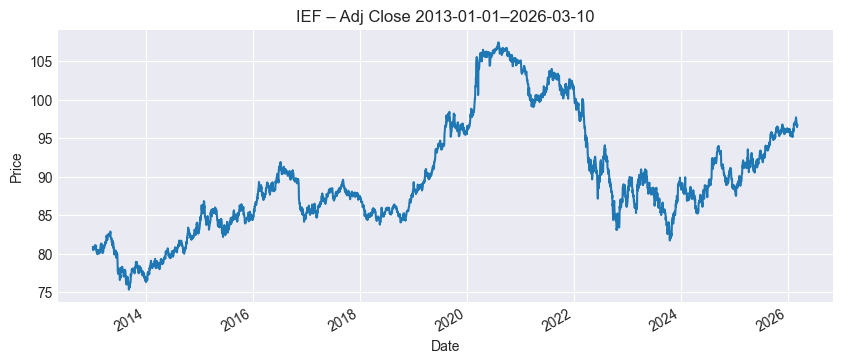

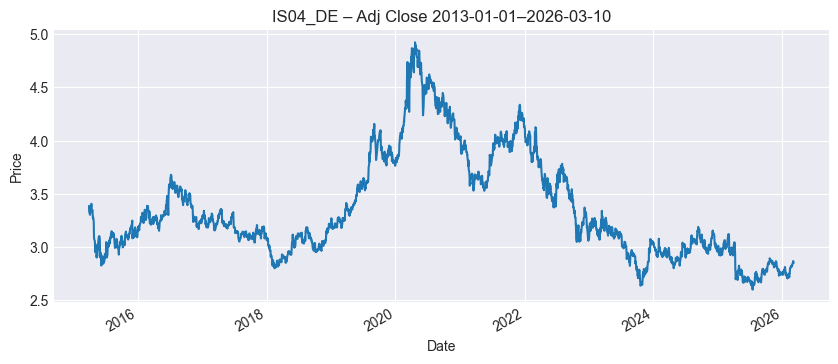

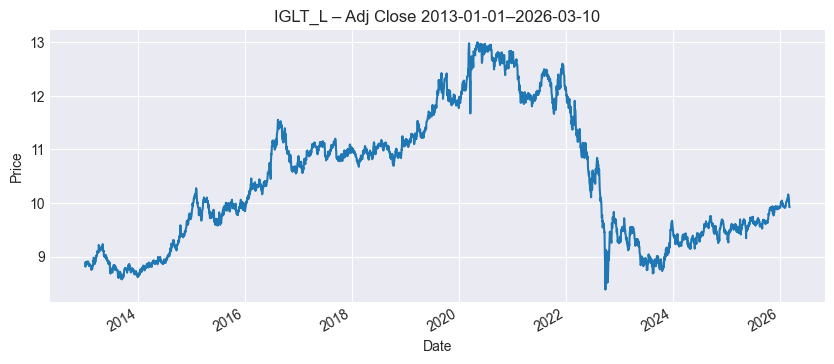

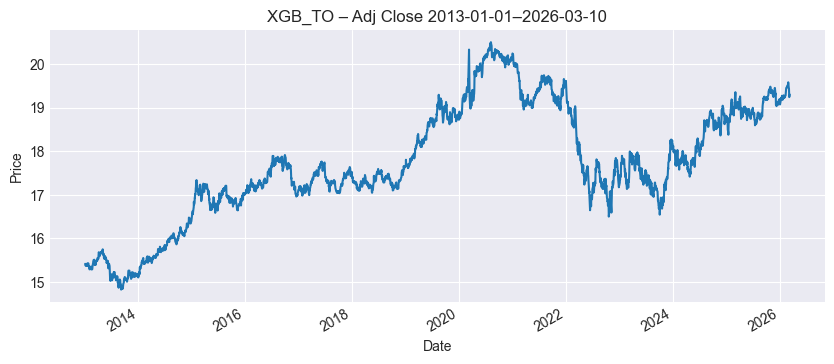

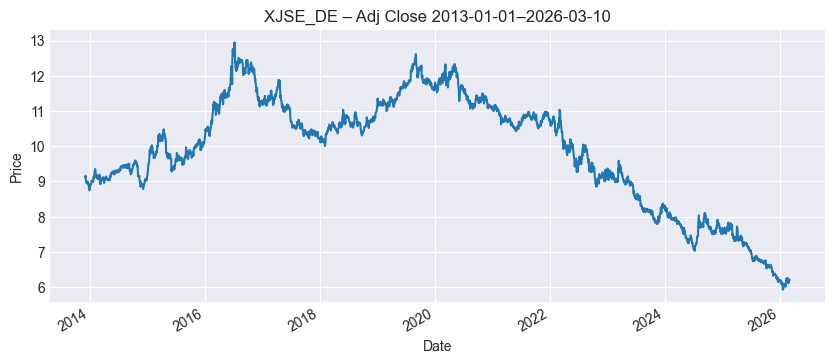

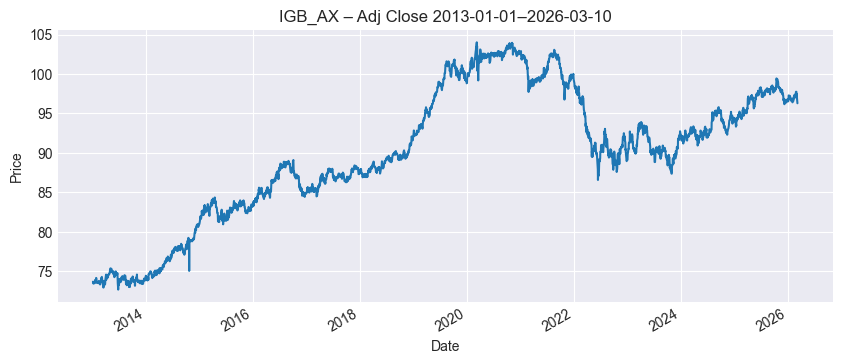

In [7]:
bond_missing = {}
for label, df in bond_etfs.items():
    missing = summarize_coverage(df, label)
    bond_missing[label] = missing

for label, df in bond_etfs.items():
    plot_series(df, label)

## FX ETFs (optional)

In [8]:
fx_etf_files = {
    "FXE": DATA_DIR / "FXE_etf_data.csv",
    "FXY": DATA_DIR / "FXY_etf_data.csv",
    "FXB": DATA_DIR / "FXB_etf_data.csv",
    "FXA": DATA_DIR / "FXA_etf_data.csv",
    "FXC": DATA_DIR / "FXC_etf_data.csv",
}

fx_etfs = {}
for label, path in fx_etf_files.items():
    if path.exists():
        df = read_price_csv(path)
        fx_etfs[label] = df
        print(f"Loaded {label} from {path.name}: {len(df)} rows in window")
    else:
        print(f"Missing file for {label}: {path}")

Loaded FXE from FXE_etf_data.csv: 3315 rows in window
Loaded FXY from FXY_etf_data.csv: 3315 rows in window
Loaded FXB from FXB_etf_data.csv: 3315 rows in window
Loaded FXA from FXA_etf_data.csv: 3315 rows in window
Loaded FXC from FXC_etf_data.csv: 3315 rows in window


FXE: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126
FXY: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126
FXB: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126
FXA: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126
FXC: 2013-01-02 → 2026-03-09, rows=3315, missing_bd_obs=126


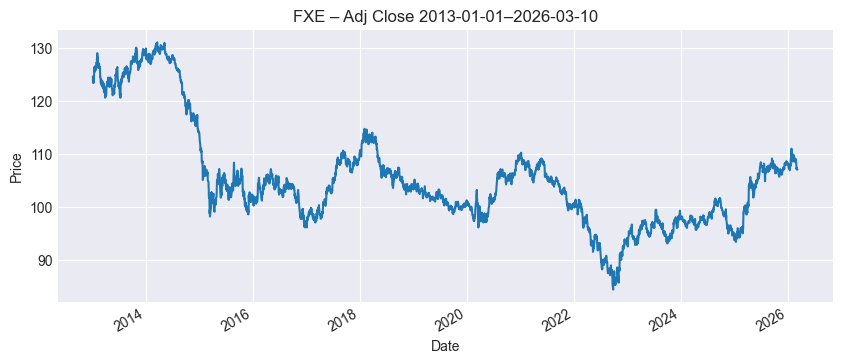

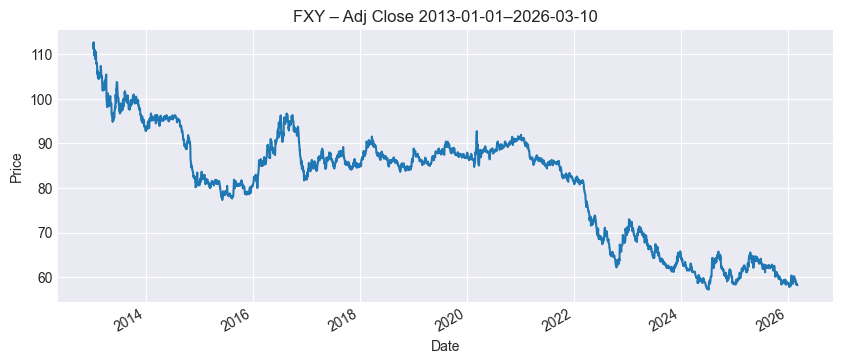

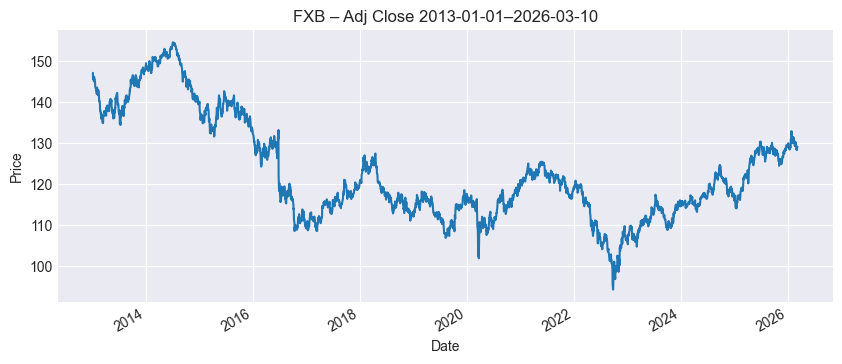

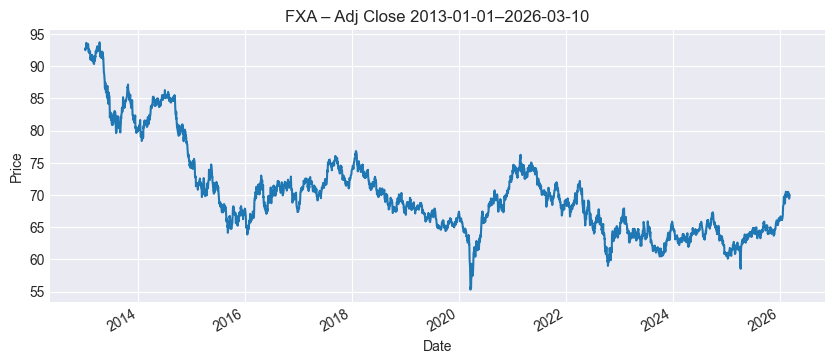

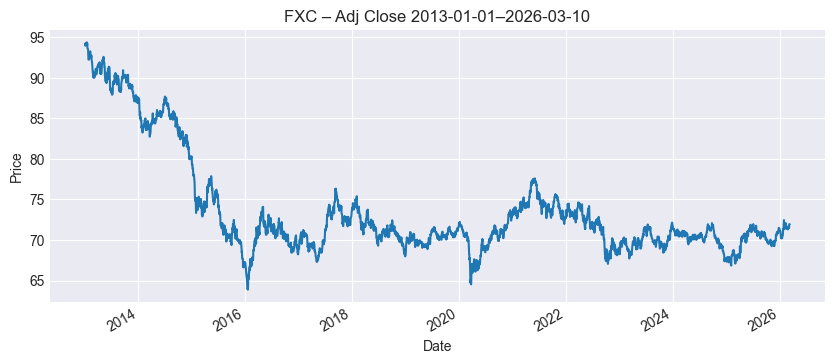

In [9]:
fx_missing = {}
for label, df in fx_etfs.items():
    missing = summarize_coverage(df, label)
    fx_missing[label] = missing

for label, df in fx_etfs.items():
    plot_series(df, label)

### High-level coverage summary

Here we assemble a quick overview of which instruments have how many observations and how many missing NYSE business days in the analysis window.

In [10]:
summary_rows = []

def add_summary_from_dict(d, group):
    full_range = pd.date_range(START_DATE, END_DATE, freq="B")
    for label, df in d.items():
        aligned = df.reindex(full_range)
        col = "Adj Close" if "Adj Close" in aligned.columns else aligned.columns[0]
        missing = aligned[col].isna().sum()
        summary_rows.append({
            "group": group,
            "instrument": label,
            "first_date": df.index.min().date() if not df.empty else None,
            "last_date": df.index.max().date() if not df.empty else None,
            "rows_in_window": len(df),
            "missing_business_days": int(missing),
        })

add_summary_from_dict(commodity_etfs, "commodity_etf")
add_summary_from_dict(bond_etfs, "bond_etf")
add_summary_from_dict(fx_etfs, "fx_etf")

summary_df = pd.DataFrame(summary_rows)
summary_df.sort_values(["group", "instrument"])

,group,instrument,first_date,last_date,rows_in_window,missing_business_days
5,bond_etf,IEF,2013-01-02,2026-03-09,3315,126
10,bond_etf,IGB_AX,2013-01-02,2026-03-09,3337,104
7,bond_etf,IGLT_L,2013-01-02,2026-03-09,3331,110
6,bond_etf,IS04_DE,2015-04-01,2026-03-05,2773,668
8,bond_etf,XGB_TO,2013-01-02,2026-03-09,3308,133
9,bond_etf,XJSE_DE,2013-12-02,2026-03-05,3109,332
3,commodity_etf,CORN,2013-01-02,2026-03-09,3315,126
2,commodity_etf,GLD,2013-01-02,2026-03-09,3315,126
1,commodity_etf,UNG,2013-01-02,2026-03-09,3315,126
0,commodity_etf,USO,2013-01-02,2026-03-09,3315,126


In [11]:
# Load and pivot BIS FX rates (AUD, CAD, EUR, JPY, GBP vs USD)
import pandas as pd

bis_path = DATA_DIR / "bis_exchange_rates_1984_present.csv"

if bis_path.exists():
    # BIS file has an unnamed index column we can drop
    bis_raw = pd.read_csv(bis_path)
    # Keep only needed columns
    cols = [
        "FREQ",
        "REF_AREA",
        "CURRENCY",
        "TIME_PERIOD",
        "OBS_VALUE",
    ]
    bis = bis_raw[cols].rename(columns={"TIME_PERIOD": "Date", "OBS_VALUE": "Rate"})

    # Filter for our currencies of interest
    target_ccy = ["AUD", "CAD", "EUR", "JPY", "GBP"]
    bis = bis[bis["CURRENCY"].isin(target_ccy)].copy()

    # Parse dates and restrict to our window
    bis["Date"] = pd.to_datetime(bis["Date"])
    bis = bis[(bis["Date"] >= START_DATE) & (bis["Date"] <= END_DATE)]

    # Pivot to wide format: one column per currency
    bis_pivot = bis.pivot_table(
        index="Date", columns="CURRENCY", values="Rate"
    ).sort_index()

    print("BIS FX pivot head:")
    display(bis_pivot.head())
else:
    print("Missing BIS FX file:", bis_path)

BIS FX pivot head:


CURRENCY,AUD,CAD,EUR,GBP,JPY
Date,,,,,
2013-01-02,0.952873,0.984769,0.754034,0.613784,87.000452
2013-01-03,0.951839,0.986338,0.763242,0.618799,86.956190
2013-01-04,0.960191,0.991162,0.768521,0.624270,88.349216
2013-01-07,0.952604,0.987116,0.766930,0.622517,87.798144
2013-01-08,0.952621,0.985710,0.764175,0.622421,87.543940


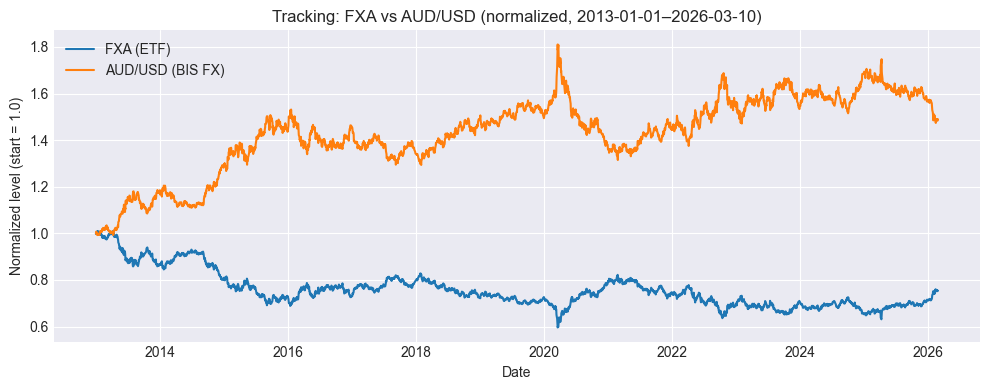

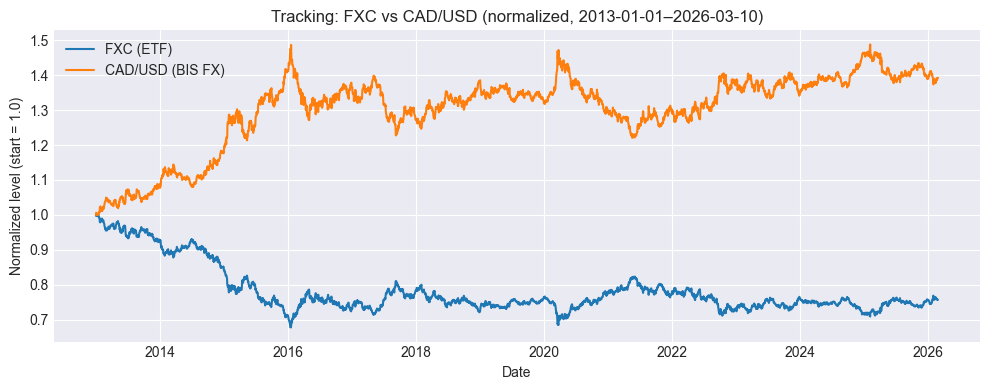

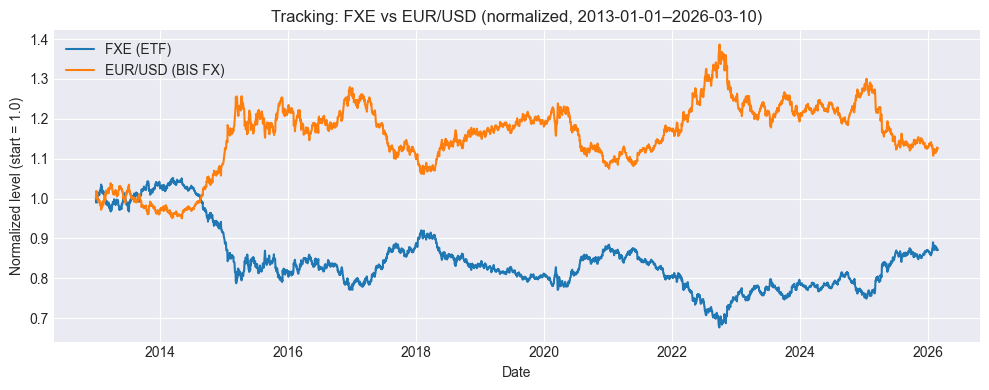

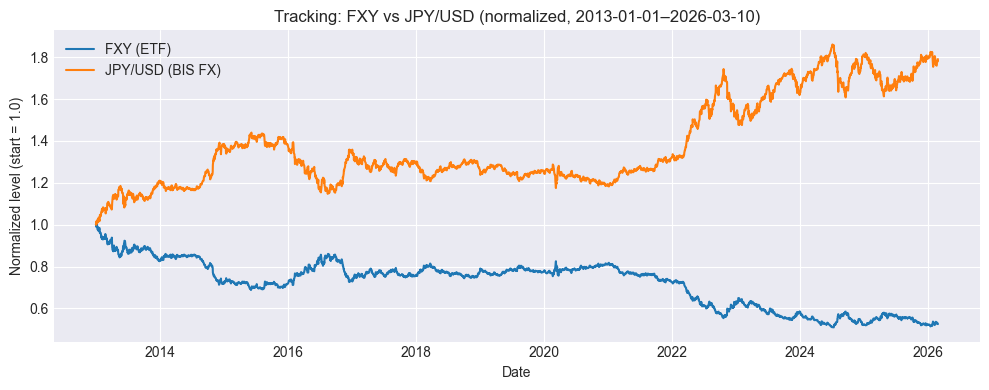

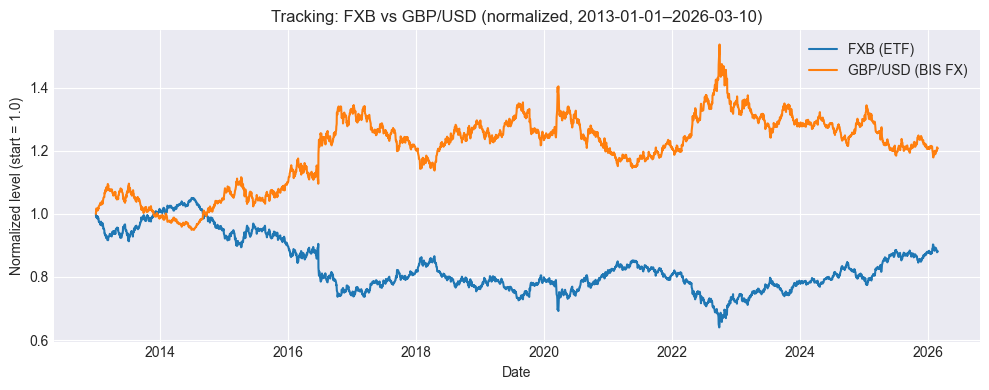

In [12]:
# Align BIS FX with FX ETFs and plot for comparison
import matplotlib.pyplot as plt

if "bis_pivot" in globals() and fx_etfs:
    # Map ETFs to their underlying currencies
    etf_to_ccy = {
        "FXA": "AUD",  # AUD/USD
        "FXC": "CAD",  # CAD/USD
        "FXE": "EUR",  # EUR/USD
        "FXY": "JPY",  # JPY/USD
        "FXB": "GBP",  # GBP/USD
    }

    for etf, ccy in etf_to_ccy.items():
        if etf not in fx_etfs:
            print(f"FX ETF {etf} not loaded; skipping.")
            continue

        etf_df = fx_etfs[etf].copy()
        # Use Adj Close if available
        price_col = "Adj Close" if "Adj Close" in etf_df.columns else "Close"
        etf_series = etf_df[price_col].rename(etf)

        # Align BIS series and ETF on the same date index
        common_index = etf_series.index.intersection(bis_pivot.index)
        etf_series = etf_series.reindex(common_index)
        fx_series = bis_pivot[ccy].reindex(common_index)

        # Normalize both to 1.0 at the start for comparability
        etf_norm = etf_series / etf_series.iloc[0]
        fx_norm = fx_series / fx_series.iloc[0]

        plt.figure(figsize=(10, 4))
        plt.plot(etf_norm.index, etf_norm, label=f"{etf} (ETF)")
        plt.plot(fx_norm.index, fx_norm, label=f"{ccy}/USD (BIS FX)")
        plt.title(f"Tracking: {etf} vs {ccy}/USD (normalized, {START_DATE.date()}–{END_DATE.date()})")
        plt.xlabel("Date")
        plt.ylabel("Normalized level (start = 1.0)")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("BIS FX data or FX ETF prices not available.")

In [ ]:
# Align BIS FX with FX ETFs using inverted rates (USD/CCY)
import matplotlib.pyplot as plt

if "bis_pivot" in globals() and fx_etfs:
    # Map ETFs to their underlying currencies
    etf_to_ccy = {
        "FXA": "AUD",  # AUD/USD ETF, track USD/AUD
        "FXC": "CAD",  # CAD/USD ETF, track USD/CAD
        "FXE": "EUR",  # EUR/USD ETF, track USD/EUR
        "FXY": "JPY",  # JPY/USD ETF, track USD/JPY
        "FXB": "GBP",  # GBP/USD ETF, track USD/GBP
    }

    for etf, ccy in etf_to_ccy.items():
        if etf not in fx_etfs:
            print(f"FX ETF {etf} not loaded; skipping.")
            continue

        etf_df = fx_etfs[etf].copy()
        # Use Adj Close if available
        price_col = "Adj Close" if "Adj Close" in etf_df.columns else "Close"
        etf_series = etf_df[price_col].rename(etf)

        # Align BIS series and ETF on the same date index
        common_index = etf_series.index.intersection(bis_pivot.index)
        etf_series = etf_series.reindex(common_index)
        # BIS is quoted as CURRENCY per 1 USD; invert to get USD/CURRENCY
        fx_series = (1.0 / bis_pivot[ccy]).reindex(common_index)

        # Normalize both to 1.0 at the start for comparability
        etf_norm = etf_series / etf_series.iloc[0]
        fx_norm = fx_series / fx_series.iloc[0]

        plt.figure(figsize=(10, 4))
        plt.plot(etf_norm.index, etf_norm, label=f"{etf} (ETF)")
        plt.plot(fx_norm.index, fx_norm, label=f"USD/{ccy} (BIS FX)")
        plt.title(f"Tracking: {etf} vs USD/{ccy} (normalized, {START_DATE.date()}–{END_DATE.date()})")
        plt.xlabel("Date")
        plt.ylabel("Normalized level (start = 1.0)")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("BIS FX data or FX ETF prices not available.")